In [2]:
import pandas as pd

#  Load the dataset
file_path = "crime_time_series_diff.csv"  # Replace with the correct path
data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

# ✅ Display basic info and sample data
print(" Dataset Loaded Successfully!")
print(data.info())
print(data.head())


 Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 244538 entries, 2001-01-01 00:01:00 to 2023-07-14 23:50:00
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       244538 non-null  int64  
 1   Crime_Count_30D  244538 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 5.6 MB
None
                     Unnamed: 0  Crime_Count_30D
Date                                            
2001-01-01 00:01:00           1              9.0
2001-01-01 00:10:00           2              5.0
2001-01-01 00:15:00           3              6.0
2001-01-01 00:20:00           4              7.0
2001-01-01 01:00:00           5             17.0


In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 🧹 Drop unnecessary column
data.drop(columns=['Unnamed: 0'], inplace=True)



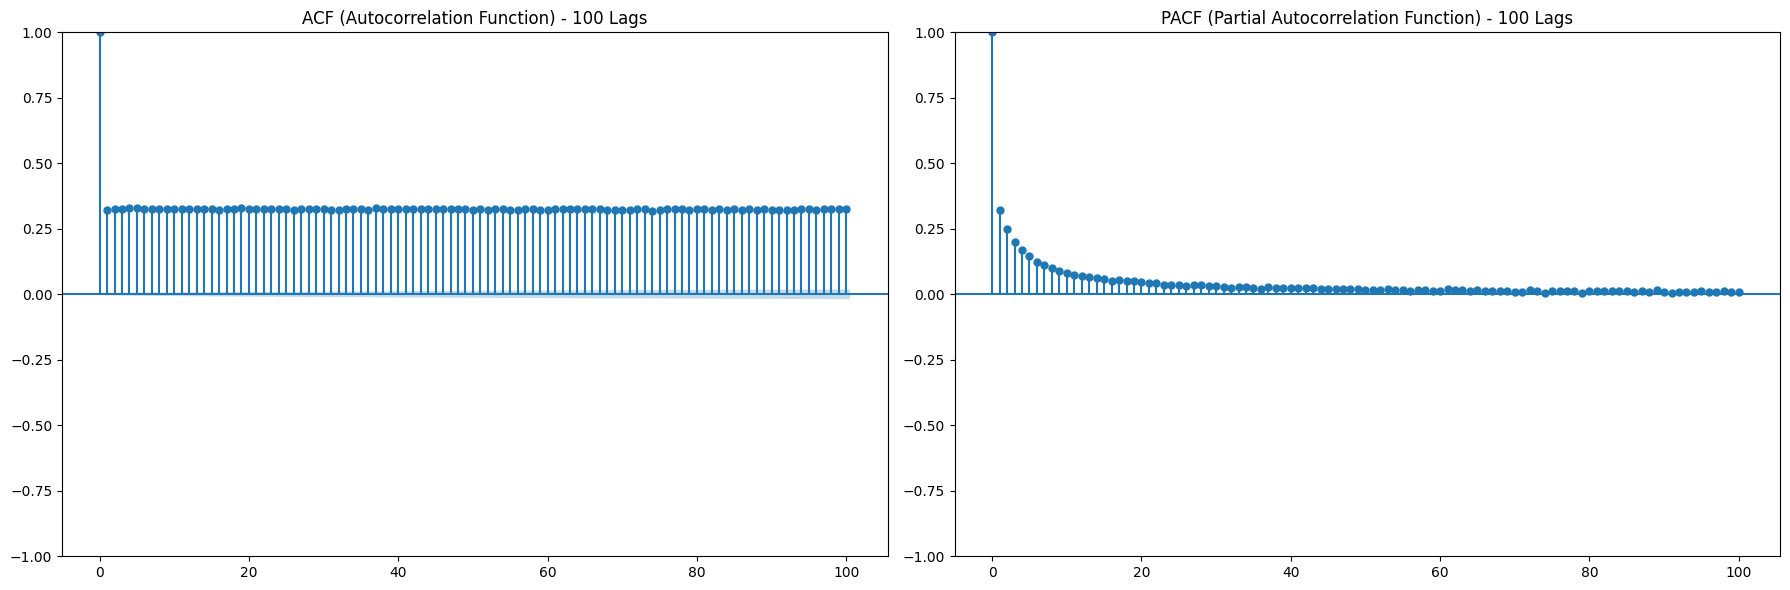

In [4]:
# 📊 Plot ACF and PACF with 100 lags
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ACF plot
plot_acf(data['Crime_Count_30D'], lags=100, ax=axes[0])
axes[0].set_title('ACF (Autocorrelation Function) - 100 Lags')

# PACF plot
plot_pacf(data['Crime_Count_30D'], lags=100, ax=axes[1])
axes[1].set_title('PACF (Partial Autocorrelation Function) - 100 Lags')

plt.tight_layout()
plt.show()



In [5]:
from statsmodels.tsa.stattools import adfuller, kpss

# Function to run ADF and KPSS tests
def test_stationarity(series):
    # ADF Test
    adf_result = adfuller(series)
    print("📊 Augmented Dickey-Fuller Test (ADF):")
    print(f"✅ ADF Statistic: {adf_result[0]}")
    print(f"✅ p-value: {adf_result[1]}")
    print(f"✅ Critical Values: {adf_result[4]}")
    if adf_result[1] < 0.05:
        print("✅ The series is likely stationary (ADF test).")
    else:
        print("❌ The series is likely non-stationary (ADF test).")
    
    print("\n")

    # KPSS Test
    kpss_result = kpss(series, nlags="auto")
    print("📊 Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS):")
    print(f"✅ KPSS Statistic: {kpss_result[0]}")
    print(f"✅ p-value: {kpss_result[1]}")
    print(f"✅ Critical Values: {kpss_result[3]}")
    if kpss_result[1] > 0.05:
        print("✅ The series is likely stationary (KPSS test).")
    else:
        print("❌ The series is likely non-stationary (KPSS test).")

# Run the tests
test_stationarity(data['Crime_Count_30D'])


📊 Augmented Dickey-Fuller Test (ADF):
✅ ADF Statistic: -8.828983377463008
✅ p-value: 1.791134221948459e-14
✅ Critical Values: {'1%': np.float64(-3.430376751135884), '5%': np.float64(-2.861551823659946), '10%': np.float64(-2.5667762933070337)}
✅ The series is likely stationary (ADF test).


📊 Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS):
✅ KPSS Statistic: 77.72645621263
✅ p-value: 0.01
✅ Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
❌ The series is likely non-stationary (KPSS test).


C:\Users\atuly\AppData\Local\Temp\ipykernel_94988\480617086.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, nlags="auto")


In [6]:
from datetime import timedelta

# 📊 Define train-test split ratio
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# 🛠️ Print dataset shapes
print(f"✅ Train Set Shape: {train.shape}")
print(f"✅ Test Set Shape: {test.shape}")

# 📅 Print the date ranges for reference
print(f"\n📅 Train Date Range: {train.index.min()} → {train.index.max()}")
print(f"📅 Test Date Range: {test.index.min()} → {test.index.max()}")

# 🧐 Preview
print("\n🔹 Train Set Preview:")
print(train.tail())
print("\n🔹 Test Set Preview:")
print(test.head())


✅ Train Set Shape: (195630, 1)
✅ Test Set Shape: (48908, 1)

📅 Train Date Range: 2001-01-01 00:01:00 → 2017-07-19 11:44:00
📅 Test Date Range: 2017-07-19 12:30:00 → 2023-07-14 23:50:00

🔹 Train Set Preview:
                     Crime_Count_30D
Date                                
2017-07-19 03:37:00            847.0
2017-07-19 05:06:00            846.0
2017-07-19 08:30:00            847.0
2017-07-19 08:45:00            848.0
2017-07-19 11:44:00            849.0

🔹 Test Set Preview:
                     Crime_Count_30D
Date                                
2017-07-19 12:30:00           1693.0
2017-07-19 13:00:00           1695.0
2017-07-19 13:20:00            848.0
2017-07-19 14:45:00            849.0
2017-07-19 14:56:00            846.0


In [7]:
# 🛠️ Downsample to daily intervals
train_daily = train.resample('D').mean()
test_daily = test.resample('D').mean()

# ✅ Check the shapes
print("Train Daily Shape:", train_daily.shape)
print("Test Daily Shape:", test_daily.shape)


Train Daily Shape: (6044, 1)
Test Daily Shape: (2187, 1)


In [8]:
# ✅ Fit SARIMA model with daily data
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define seasonality (monthly)
P, D, Q, s = 1, 1, 1, 30  # 30-day seasonality with daily intervals

warnings.filterwarnings("ignore")

sarima_model = SARIMAX(train_daily['Crime_Count_30D'],
                       order=(2, 1, 2),
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(low_memory=True)

# 📊 Print model summary
print("✅ SARIMA Model Summary:")
print(sarima_fit.summary())


✅ SARIMA Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                      Crime_Count_30D   No. Observations:                 6044
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 30)   Log Likelihood              -35283.315
Date:                              Mon, 24 Mar 2025   AIC                          70580.629
Time:                                      18:29:16   BIC                          70627.502
Sample:                                  01-01-2001   HQIC                         70596.909
                                       - 07-19-2017                                         
Covariance Type:                             approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0003      0.015     66.377      0.000       0.971       1

In [9]:
import numpy as np
# ✅ Make predictions on the test set
sarima_predictions = sarima_fit.get_forecast(steps=len(test_daily))
sarima_predicted_values = sarima_predictions.predicted_mean

# 📊 Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_sarima = np.sqrt(mean_squared_error(test_daily['Crime_Count_30D'], sarima_predicted_values))
mae_sarima = mean_absolute_error(test_daily['Crime_Count_30D'], sarima_predicted_values)
mape_sarima = np.mean(np.abs((test_daily['Crime_Count_30D'] - sarima_predicted_values) / test_daily['Crime_Count_30D'])) * 100

print("📈 SARIMA Model Evaluation Metrics:")
print(f"✅ RMSE: {rmse_sarima:.4f}")
print(f"✅ MAE: {mae_sarima:.4f}")
print(f"✅ MAPE: {mape_sarima:.4f}%")


📈 SARIMA Model Evaluation Metrics:
✅ RMSE: 170.5295
✅ MAE: 131.3294
✅ MAPE: 16.0881%


In [11]:
# 📅 Forecast future crime counts with confidence intervals
forecast_steps = [7, 30, 60, 90]
forecast_results = {}

for steps in forecast_steps:
    forecast = sarima_fit.get_forecast(steps=steps)
    forecast_dates = pd.date_range(start=test_daily.index[-1], periods=steps + 1, freq='D')[1:]
    
    # Extract confidence intervals correctly
    conf_int = forecast.conf_int(alpha=0.05)  # 95% confidence interval
    forecast_results[steps] = pd.DataFrame({
        'Date': forecast_dates,
        'Forecast_Crime_Count_30D': forecast.predicted_mean.values,
        'Lower Bound': conf_int.iloc[:, 0].values,  # Lower bound
        'Upper Bound': conf_int.iloc[:, 1].values   # Upper bound
    })

# ✅ Display corrected forecasts
for steps, df in forecast_results.items():
    print(f"\n📅 **{steps}-Day Forecast with Confidence Intervals:**")
    print(df.head())



📅 **7-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023-07-15                903.859774          NaN          NaN
1 2023-07-16                902.631029          NaN          NaN
2 2023-07-17                901.625571          NaN          NaN
3 2023-07-18                887.525030          NaN          NaN
4 2023-07-19                896.917777          NaN          NaN

📅 **30-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023-07-15                903.859774          NaN          NaN
1 2023-07-16                902.631029          NaN          NaN
2 2023-07-17                901.625571          NaN          NaN
3 2023-07-18                887.525030          NaN          NaN
4 2023-07-19                896.917777          NaN          NaN

📅 **60-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023

In [12]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 🛠️ Refit the SARIMA model without low_memory
warnings.filterwarnings("ignore")

# SARIMA Model Parameters
p, d, q = 2, 1, 2
P, D, Q, s = 1, 1, 1, 30

sarima_model = SARIMAX(
    train_daily['Crime_Count_30D'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# ✅ Fit with approximate covariance calculation
sarima_fit = sarima_model.fit(low_memory=False, cov_type='approx')

# ✅ Forecast future crime counts with confidence intervals
forecast_steps = [7, 30, 60, 90]
forecast_results = {}

for steps in forecast_steps:
    forecast = sarima_fit.get_forecast(steps=steps)
    forecast_dates = pd.date_range(start=test_daily.index[-1], periods=steps + 1, freq='D')[1:]
    
    # Extract confidence intervals correctly
    conf_int = forecast.conf_int(alpha=0.05)  # 95% confidence interval
    forecast_results[steps] = pd.DataFrame({
        'Date': forecast_dates,
        'Forecast_Crime_Count_30D': forecast.predicted_mean.values,
        'Lower Bound': conf_int.iloc[:, 0].values,
        'Upper Bound': conf_int.iloc[:, 1].values
    })

# ✅ Display corrected forecasts
for steps, df in forecast_results.items():
    print(f"\n📅 **{steps}-Day Forecast with Confidence Intervals:**")
    print(df.head())



📅 **7-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023-07-15                903.859774   701.978977  1105.740571
1 2023-07-16                902.631029   697.366930  1107.895128
2 2023-07-17                901.625571   693.434091  1109.817051
3 2023-07-18                887.525030   676.511427  1098.538633
4 2023-07-19                896.917777   683.178096  1110.657457

📅 **30-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023-07-15                903.859774   701.978977  1105.740571
1 2023-07-16                902.631029   697.366930  1107.895128
2 2023-07-17                901.625571   693.434091  1109.817051
3 2023-07-18                887.525030   676.511427  1098.538633
4 2023-07-19                896.917777   683.178096  1110.657457

📅 **60-Day Forecast with Confidence Intervals:**
        Date  Forecast_Crime_Count_30D  Lower Bound  Upper Bound
0 2023

In [13]:
import plotly.graph_objects as go

# 📊 Visualization Function
def plot_forecasts_with_ci(forecast_results, test_data, title="SARIMA Forecast"):
    fig = go.Figure()

    # 📉 Add Actual Values
    fig.add_trace(go.Scatter(
        x=test_data.index, 
        y=test_data['Crime_Count_30D'],
        mode='lines',
        name='Actual Crime Count',
        line=dict(color='blue')
    ))

    # 🎯 Add Forecasts with Confidence Intervals
    colors = ['green', 'orange', 'red', 'purple']
    forecast_labels = ['7-Day Forecast', '30-Day Forecast', '60-Day Forecast', '90-Day Forecast']

    for idx, (steps, df) in enumerate(forecast_results.items()):
        fig.add_trace(go.Scatter(
            x=df['Date'],
            y=df['Forecast_Crime_Count_30D'],
            mode='lines+markers',
            name=forecast_labels[idx],
            line=dict(color=colors[idx])
        ))

        # Add Confidence Interval Shading
        fig.add_trace(go.Scatter(
            x=df['Date'].tolist() + df['Date'].tolist()[::-1],
            y=(df['Upper Bound'].tolist() + df['Lower Bound'].tolist()[::-1]),
            fill='toself',
            fillcolor=colors[idx],
            line=dict(width=0),
            opacity=0.2,
            name=f"{forecast_labels[idx]} CI"
        ))

    # 📊 Plot Settings
    fig.update_layout(
        title=title,
        xaxis_title='Date',
        yaxis_title='Crime Count (30D)',
        template='plotly_dark',
        legend=dict(x=0, y=1),
        height=700,
        width=1300
    )
    fig.show()

# 🛠️ Plot all forecasts
plot_forecasts_with_ci(forecast_results, test_daily)


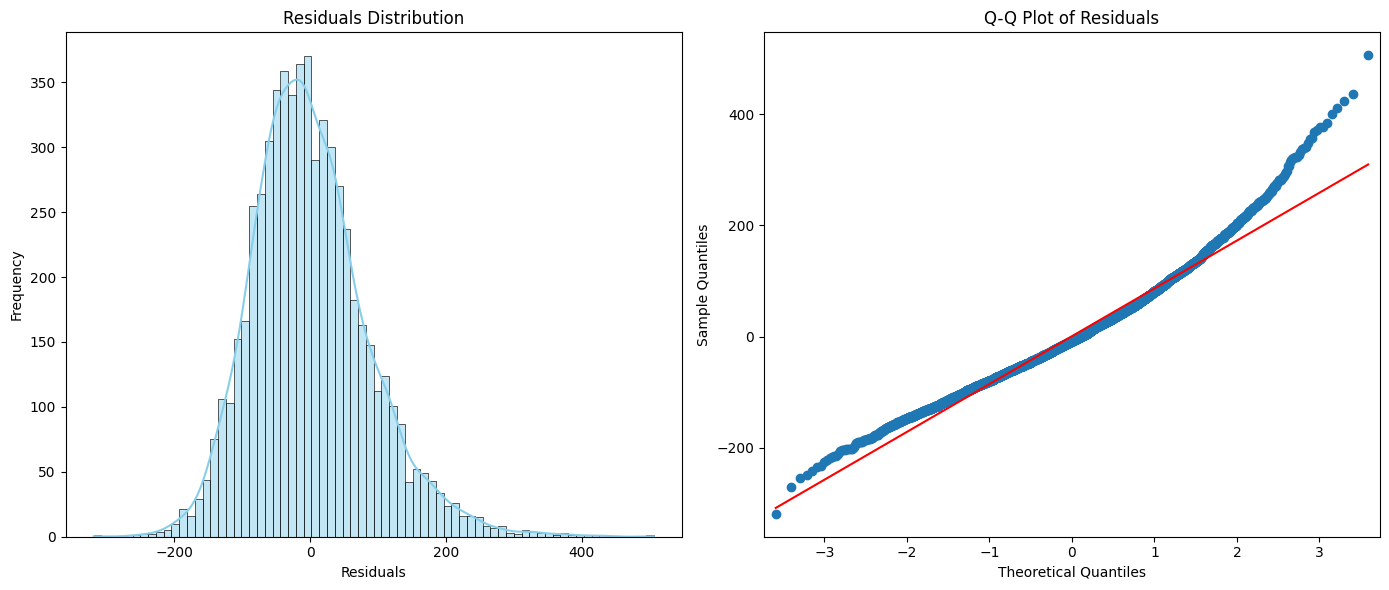

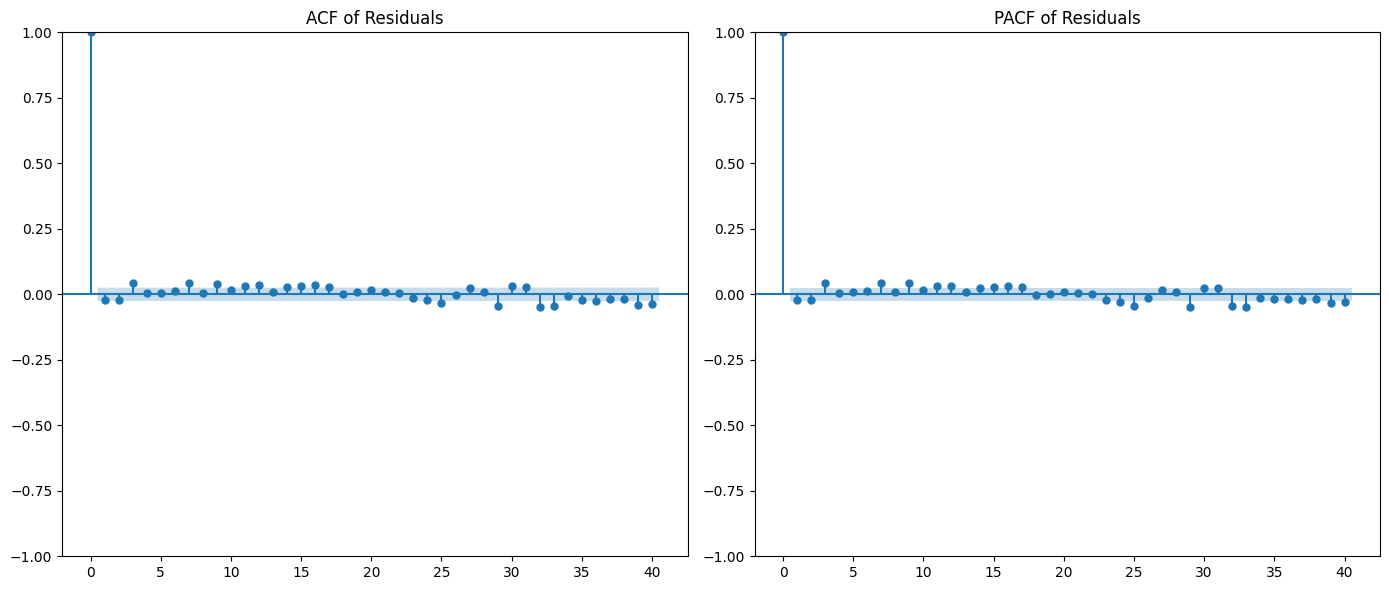

In [16]:
import statsmodels.api as sm
import plotly.express as px
import seaborn  as sns
# 📊 Get residuals
residuals = sarima_fit.resid

# 📉 Plot Residuals
fig = px.line(residuals, title="SARIMA Residuals", labels={'value': 'Residuals', 'index': 'Date'})
fig.update_traces(line_color='orange')
fig.show()

# ✅ Residual Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 📈 Histogram of Residuals
sns.histplot(residuals, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Residuals Distribution')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# 📉 Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# ✅ Autocorrelation and Partial Autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sm.graphics.tsa.plot_acf(residuals, lags=40, ax=axes[0], title="ACF of Residuals")
sm.graphics.tsa.plot_pacf(residuals, lags=40, ax=axes[1], title="PACF of Residuals")

plt.tight_layout()
plt.show()


In [17]:
import joblib

# 📌 Define the path to save the model
model_path = "sarima_model.pkl"

# ✅ Save the model
joblib.dump(sarima_fit, model_path)
print(f"✅ SARIMA model saved at: {model_path}")


✅ SARIMA model saved at: sarima_model.pkl


In [18]:
# 📌 Load the saved model
sarima_loaded = joblib.load("sarima_model.pkl")

# ✅ Confirm the model is loaded
print("✅ SARIMA model loaded successfully!")
print(sarima_loaded.summary())


✅ SARIMA model loaded successfully!
                                      SARIMAX Results                                       
Dep. Variable:                      Crime_Count_30D   No. Observations:                 6044
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 30)   Log Likelihood              -35283.315
Date:                              Mon, 24 Mar 2025   AIC                          70580.629
Time:                                      19:00:06   BIC                          70627.502
Sample:                                  01-01-2001   HQIC                         70596.909
                                       - 07-19-2017                                         
Covariance Type:                             approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0003      0.015     66.377      0.000       0

In [19]:
# Forecast using the loaded model
forecast = sarima_loaded.get_forecast(steps=30)
forecast_df = forecast.conf_int()
forecast_df['Forecast'] = forecast.predicted_mean

# ✅ Display forecast
print(forecast_df.head())


            lower Crime_Count_30D  upper Crime_Count_30D    Forecast
2017-07-20             701.978977            1105.740571  903.859774
2017-07-21             697.366930            1107.895128  902.631029
2017-07-22             693.434091            1109.817051  901.625571
2017-07-23             676.511427            1098.538633  887.525030
2017-07-24             683.178096            1110.657457  896.917777
